In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("smartcart_customers.csv")

In [4]:
X = data.drop("ID", axis = 1)
X.isnull().sum()

Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
X["Income"] =X["Income"].fillna(X["Income"].median()) 

X.isnull().sum()

Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [6]:
X["age"] = 2026- X["Year_Birth"]

X["Dt_Customer"] = pd.to_datetime(X["Dt_Customer"], dayfirst = True)
X["Customer_Tenure_Days"] = (X["Dt_Customer"].max() - X["Dt_Customer"]).dt.days


X["Total_spending"] = X["MntWines"] + X["MntGoldProds"] + X["MntFruits"] + X["MntMeatProducts"] + X["MntFishProducts"] + X["MntSweetProducts"]


X["Total_childs"] = X["Kidhome"] + X["Teenhome"]
X

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_spending,Total_childs
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,8,10,4,7,0,1,69,663,1617,0
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,1,1,2,5,0,0,72,113,27,2
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,8,2,10,4,0,0,61,312,776,0
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,2,0,4,6,0,0,42,139,53,1
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,5,3,6,5,0,0,45,161,422,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,43,...,9,3,4,5,0,0,59,381,1341,1
2236,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,0,...,8,2,5,7,0,0,80,19,444,3
2237,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,48,...,2,3,13,6,0,0,45,155,1241,0
2238,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,30,...,6,5,10,3,0,0,70,156,843,1


In [7]:
X["Education"].value_counts()


Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [8]:
X["Education"] = X["Education"].replace({
    "Basic": "UnderGraduated",
    "2n Cycle": "UnderGraduated",
    "Graduation": "Graduation",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

In [9]:
X["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [10]:
#Marital Status
X ["Living_With"] =  X["Marital_Status"].replace({
"Married": "Partner", "Together": "Partner", "Single": "Alone", "Divorced": "Alone", "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

In [11]:
cols = ["Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
cols_to_drop = cols + spending_cols
X_clean = X.drop(columns = cols_to_drop)

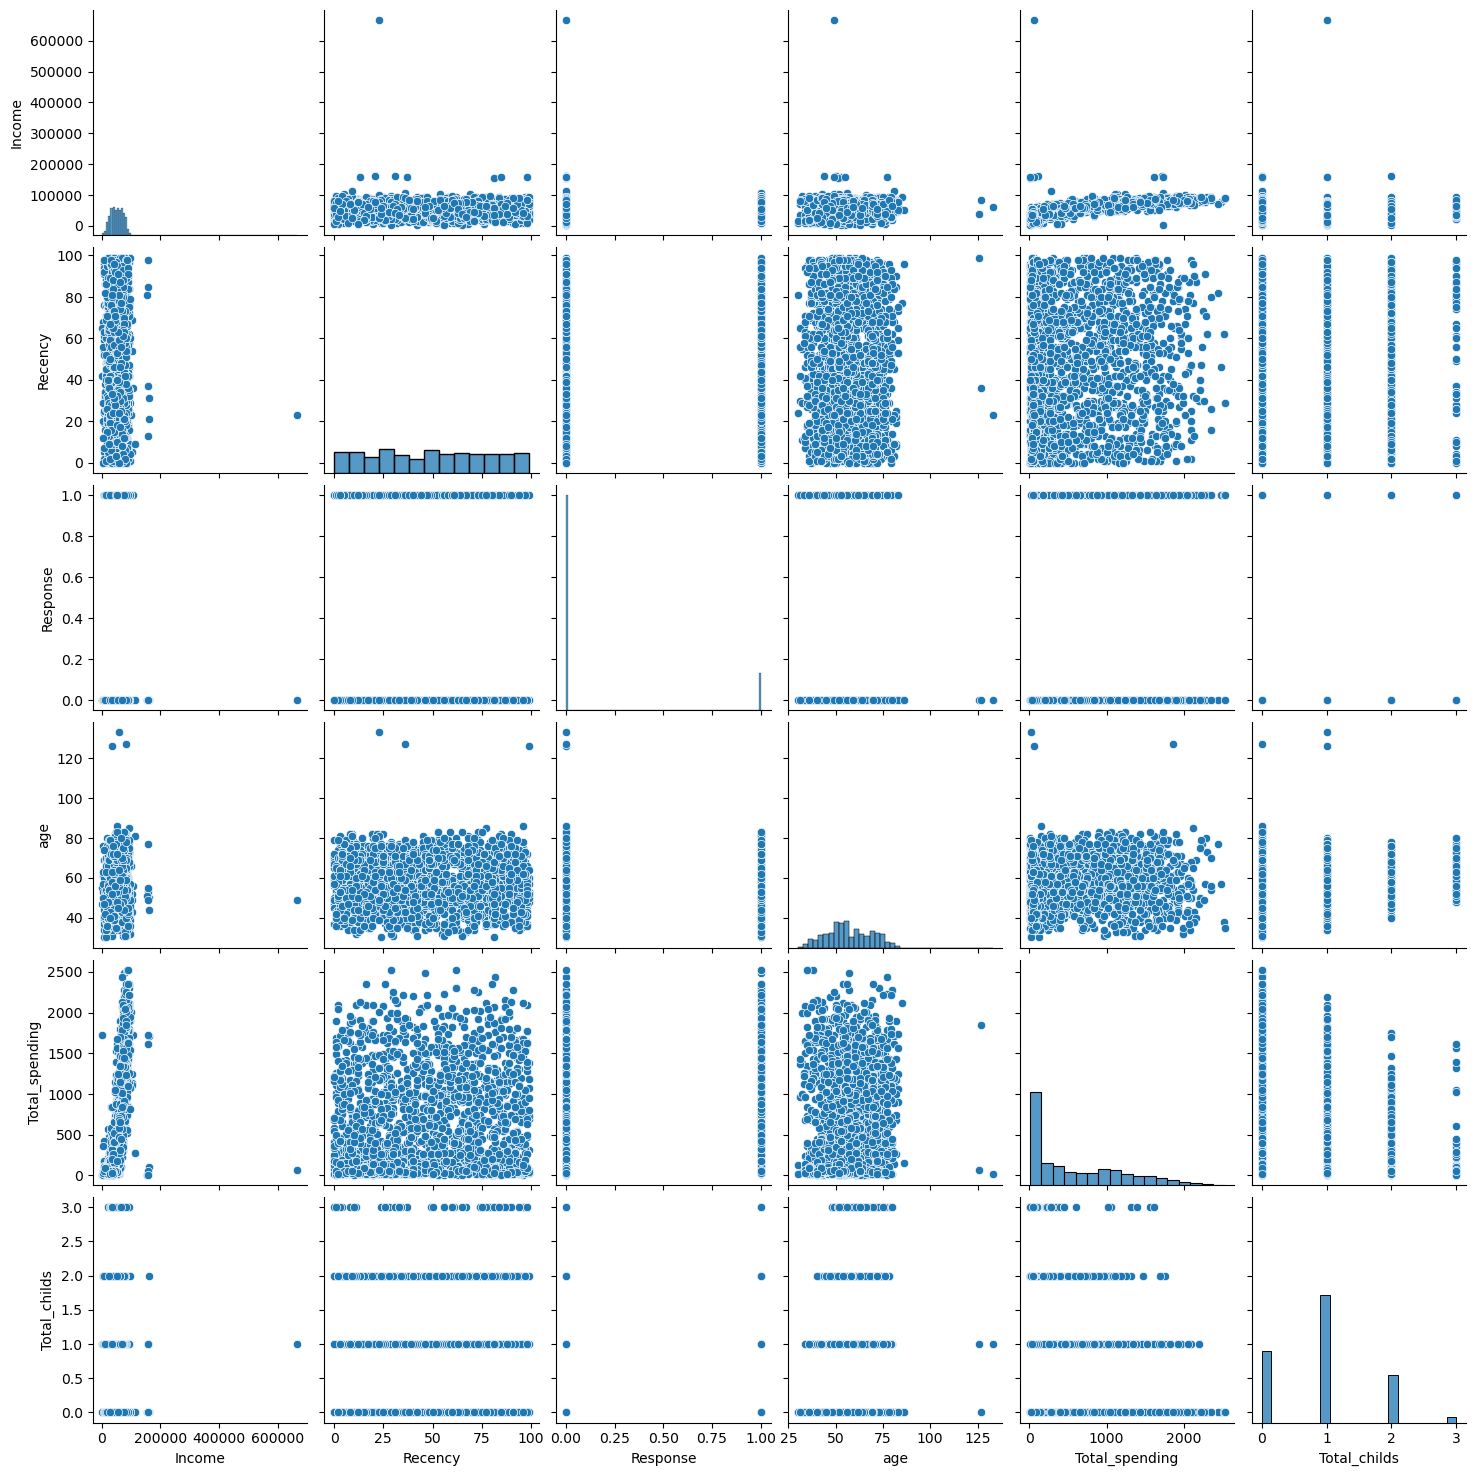

In [12]:
coln =  ["Income", "Recency", "Response", "age", "Total_spending", "Total_childs"]
sns.pairplot(X_clean[coln])

In [13]:
X_clean = X_clean[(X_clean["Income"]<600000)]
X_clean = X_clean[(X_clean["age"]<90)]

<Axes: >

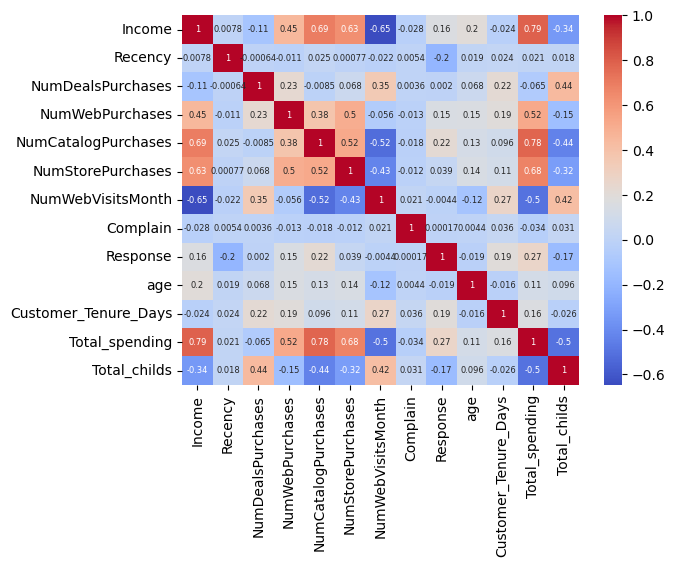

In [14]:

cor = X_clean.corr(numeric_only = True)
sns.heatmap(
    cor,
    annot = True,
    annot_kws = {"size" : 6},
    cmap = "coolwarm"
)

In [15]:
X_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Education             2236 non-null   object 
 1   Income                2236 non-null   float64
 2   Recency               2236 non-null   int64  
 3   NumDealsPurchases     2236 non-null   int64  
 4   NumWebPurchases       2236 non-null   int64  
 5   NumCatalogPurchases   2236 non-null   int64  
 6   NumStorePurchases     2236 non-null   int64  
 7   NumWebVisitsMonth     2236 non-null   int64  
 8   Complain              2236 non-null   int64  
 9   Response              2236 non-null   int64  
 10  age                   2236 non-null   int64  
 11  Customer_Tenure_Days  2236 non-null   int64  
 12  Total_spending        2236 non-null   int64  
 13  Total_childs          2236 non-null   int64  
 14  Living_With           2236 non-null   object 
dtypes: float64(1), int64(12), 

In [16]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

categorical_cols = ["Education", "Living_With"]

encoded = encoder.fit_transform(X_clean[categorical_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_clean.index
)

X_clean = X_clean.drop(columns=categorical_cols)

X_clean = pd.concat([X_clean, encoded_df], axis=1)

In [17]:
X_clean.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_spending,Total_childs,Education_Graduation,Education_Postgraduate,Education_UnderGraduated,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [18]:
print(X_clean.dtypes)

Income                      float64
Recency                       int64
NumDealsPurchases             int64
NumWebPurchases               int64
NumCatalogPurchases           int64
NumStorePurchases             int64
NumWebVisitsMonth             int64
Complain                      int64
Response                      int64
age                           int64
Customer_Tenure_Days          int64
Total_spending                int64
Total_childs                  int64
Education_Graduation        float64
Education_Postgraduate      float64
Education_UnderGraduated    float64
Living_With_Alone           float64
Living_With_Partner         float64
dtype: object


In [19]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()
X_scale = scale.fit_transform(X_clean)

In [20]:
#PCA
from sklearn.decomposition import PCA

pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scale)

In [21]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Elbow Method

In [22]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

C:\Users\Krishna Verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\Krishna Verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\Krishna Verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\Krishna Verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

In [23]:
knee = KneeLocator(range(1,11), wcss, curve = "convex", direction = "decreasing")
print("Best K: ", knee.elbow)

Best K:  4


C:\Users\Krishna Verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\Krishna Verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\Krishna Verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\Krishna Verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

Text(0, 0.5, 'Silhouette score')

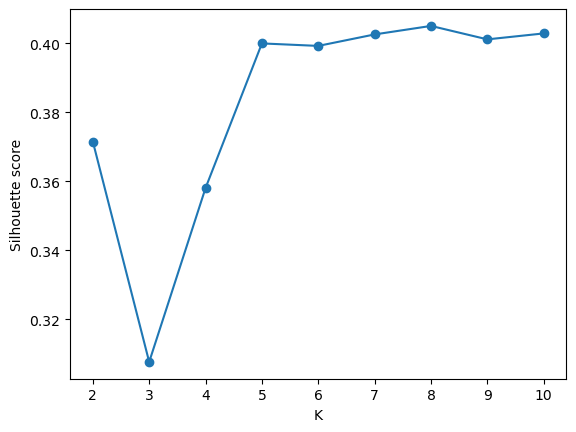

In [24]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

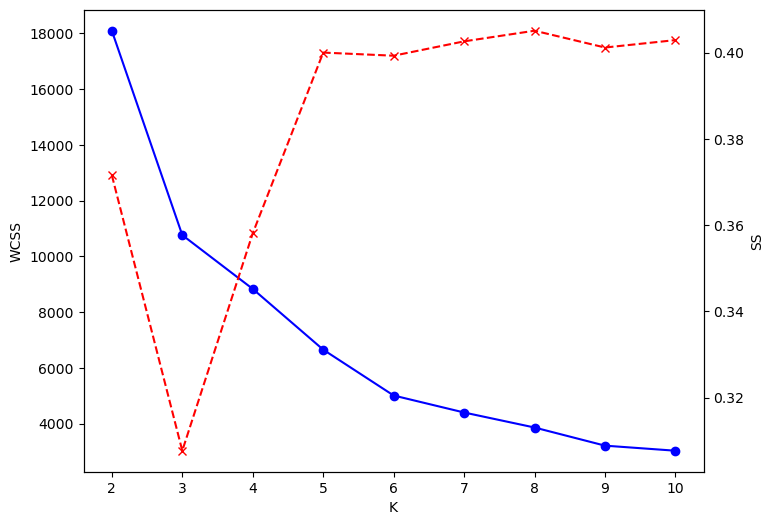

In [25]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

In [26]:
# K_means

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

C:\Users\Krishna Verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


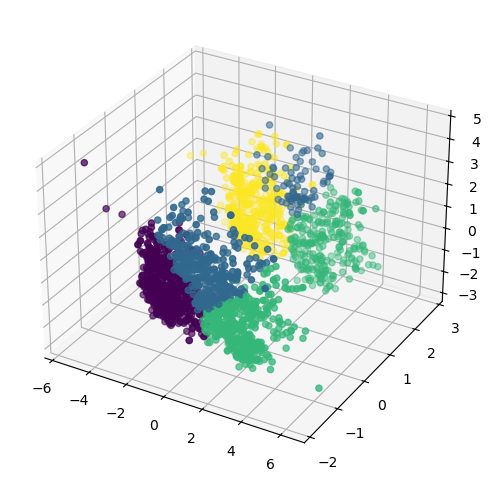

In [27]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

In [28]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

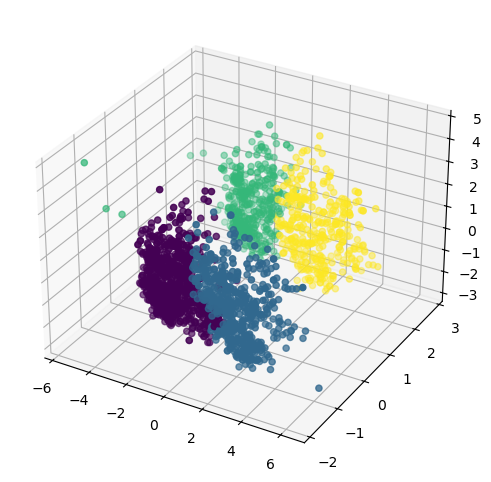

In [29]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

In [30]:
X_clean["Cluster"] = labels_agg


<Axes: xlabel='Cluster', ylabel='count'>

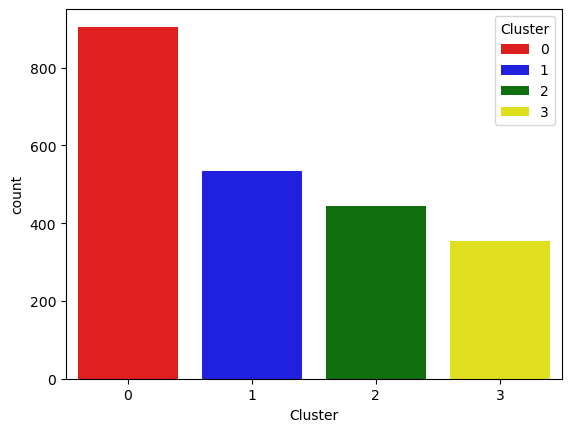

In [31]:
color = ["red","blue","green","yellow"]
sns.countplot(x = X_clean["Cluster"], palette = color, hue = X_clean["Cluster"])

In [33]:
cluster_summary = X_clean.groupby("Cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
Cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        age  Customer_Tenure_Days  Total_spending  \
Cluster         